In [14]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

from firedrake.checkpointing import DumbCheckpoint

from firedrake import *

### Import our homemade functions ###
import scripts.model_modules
from scripts.mesh_generating import *



%matplotlib widget

# 1. Load the necessary data

### 1.1 Borehole locations

In [3]:
### Load boreholes
borehole_locations = pd.read_csv('Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

# Do the meshing

In [4]:
upscale_factor_fine = 1/10
src_bed_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif"
src_surf_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif"
layer_num=5

In [5]:
mesh_fine = mesh_creator(src_bed_fine_path, src_surf_fine_path, resamp_factor=upscale_factor_fine, layers=layer_num)
x_src, y_src, z_src = SpatialCoordinate(mesh_fine)

pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)

chk = DumbCheckpoint("Saved_Models/fine_mesh_flow_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(flow, name="fine_mesh_flow")

u,p = firedrake.split(flow)

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


# Load the temperature field

In [6]:
V = firedrake.FunctionSpace(mesh_fine, "CG", 1)

T = firedrake.Function(V)

chk = DumbCheckpoint("Saved_Models/fine_mesh_temperature_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(T, name="fine_mesh_temp")

T_init = T.copy(deepcopy=True)

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


In [8]:
mesh_fine.coordinates

Coefficient(WithGeometry(FunctionSpace(<firedrake.mesh.ExtrudedMeshTopology object at 0x7f8e490ba1b0>, VectorElement(TensorProductElement(FiniteElement('Lagrange', triangle, 1), FiniteElement('Lagrange', interval, 1), cell=TensorProductCell(triangle, interval)), dim=3), name=None), Mesh(VectorElement(TensorProductElement(FiniteElement('Lagrange', triangle, 1), FiniteElement('Lagrange', interval, 1), cell=TensorProductCell(triangle, interval)), dim=3), 8)), 27)

# 2. Make the temperature time stepping

In [6]:
δx = mesh_fine.cell_sizes.dat.data_ro[:].min()
umax = flow.sub(0).dat.data_ro[:].max()
δt = Constant(spy/.1)

In [7]:
from ufl import Measure
dx = ufl.Measure("dx", domain=mesh_fine)


ϕ = firedrake.TestFunction(V)

geo_flux = 0.04 # W/m^2 
k = Constant(2.22)  # W / m C

geothermal_flux = -geo_flux*ϕ  * ds_b
F_diffusion = k*inner(grad(T), grad(ϕ)) * dx
F_advection = - ρ * c * T * inner(u, grad(ϕ)) * dx

F = ρ * c * Dt(T) * ϕ * dx + F_diffusion + F_advection + geothermal_flux

In [8]:
mag = 2

T_mean = Constant(-33) #average temp (C)
T_Mean = -33 #average temp (C)

temperature_expr = T_mean - (z_src - 2000)*.01

surface_temp_bc = firedrake.DirichletBC(V, temperature_expr, 'top')

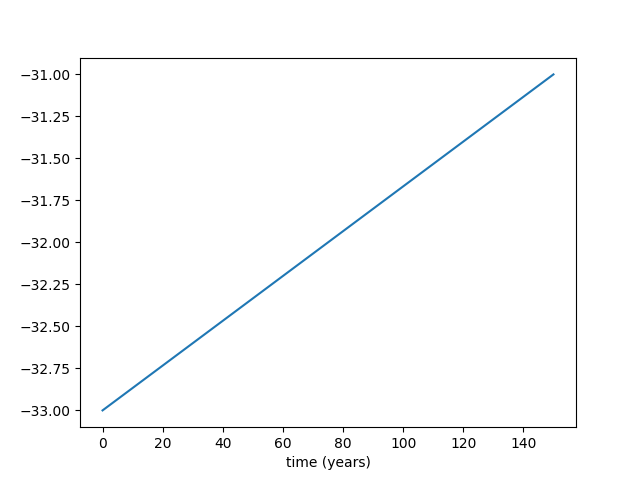

In [9]:
δT = 25.0
θ = 1 * π / 2
year = spy
years = 150
final_time = years * spy # years modeling * spy


freq = 1 # 1 for annual cycle
num_steps = int(final_time / float(δt))

# def surface_temperature(t):
#     return T_Mean + δT * np.sin(2 * π *freq* t / year + θ) + (t/final_time)*1

def surface_temperature(t):
    return T_Mean + (t/final_time)*mag

ts = np.linspace(0.0, final_time, num_steps + 1)

surface_temps = surface_temperature(ts)

fig, ax = plt.subplots()

ax.set_xlabel("time (years)")
#ax.set_ylabel("temperature (${}^\circ$C)")
ax.plot(ts / spy, surface_temps);

In [ ]:
# surface_temps = np.array([-30.5 , -30.5, -30.5, -30.9, -31, -31.5 , -31.8, -32, -32.2, -32.4, -32. ])

# fig, ax = plt.subplots()

# ax.set_xlabel("time (years)")
# #ax.set_ylabel("temperature (${}^\circ$C)")
# ax.plot(ts / spy, surface_temps);

In [10]:
method = irksome.BackwardEuler()
temperature_solver = irksome.TimeStepper(F, method, Constant(0.0), δt, T, bcs=surface_temp_bc)

In [11]:
import tqdm
final_time = years* spy 
num_steps = int(final_time / float(δt))
Ts = [T.copy(deepcopy=True)]

for step in tqdm.trange(num_steps):
    t = ts[step]
    T_mean.assign(surface_temperature(t))

    temperature_solver.advance()


    Ts.append(T.copy(deepcopy=True))


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:28<00:00,  1.92s/it]


In [12]:
x_coords_mesh, y_coords_mesh = np.unique(mesh_fine.coordinates.dat.data_ro[:,0]), np.unique(mesh_fine.coordinates.dat.data_ro[:,1])
bed_of_mesh_coords = []
for x_co in x_coords_mesh:
    for y_co in y_coords_mesh:
        z_s =[]
        for x,y,z in zip(mesh_fine.coordinates.dat.data_ro[:,0], mesh_fine.coordinates.dat.data_ro[:,1], mesh_fine.coordinates.dat.data_ro[:,2]):

            if (x_co, y_co) == (x,y):
                z_s.append(z)

        z_min = np.array(z_s).min()

        bed_of_mesh_coords.append((x_co, y_co, z_min))

bed_of_mesh_coords_arr = np.array(bed_of_mesh_coords)

In [13]:
temp_dict_climate = {}
temp_dict_no_climate = {}

for x_bore, y_bore, name_bore in zip(transformed_x, transformed_y, borehole_locations['Core']):
    distance_to_closest_node = np.sqrt((bed_of_mesh_coords_arr[:,0]-x_bore)**2+(bed_of_mesh_coords_arr[:,1]-y_bore)**2).min()
    if distance_to_closest_node > 100:
        continue

    closest_node_loc = np.argmin(np.sqrt((bed_of_mesh_coords_arr[:,0]-x_bore)**2+(bed_of_mesh_coords_arr[:,1]-y_bore)**2))
    profile_coords = []

    x_interest, y_interest = np.float64(bed_of_mesh_coords_arr[:,0][closest_node_loc]), np.float64(bed_of_mesh_coords_arr[:,1][closest_node_loc])
    temp_clim_vals = []
    temp_no_clim_vals = []
    for x,y,z in zip(mesh_fine.coordinates.dat.data_ro[:,0], mesh_fine.coordinates.dat.data_ro[:,1], mesh_fine.coordinates.dat.data_ro[:,2]):

        if (x_interest, y_interest) == (x,y):
            profile_coords.append((x,y,z))

            temp_clim_vals.append(Ts[-1].at(x, y, z))
            temp_no_clim_vals.append(T_init.at(x, y, z))
    if len(temp_clim_vals) > 0:
        temp_dict_climate[name_bore] = [np.array(temp_clim_vals), np.array(profile_coords)]
        temp_dict_no_climate[name_bore] = [np.array(temp_no_clim_vals), np.array(profile_coords)]

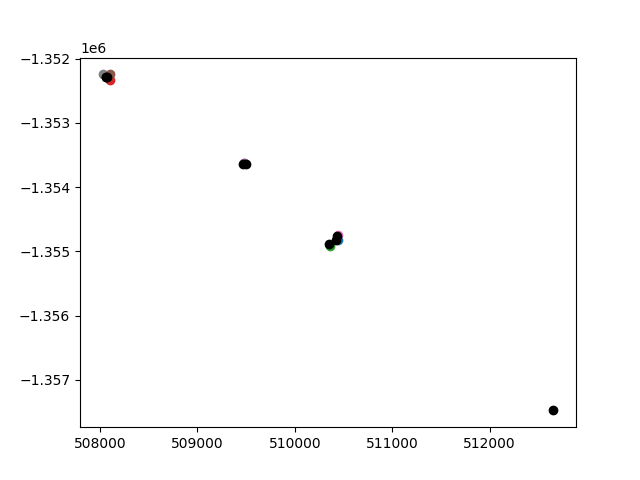

In [23]:
fig,ax = plt.subplots()

for i in temp_dict_climate:
    ax.scatter(temp_dict_climate[i][1][0][0], temp_dict_climate[i][1][0][1])

ax.scatter(transformed_x, transformed_y, c='black')



In [25]:
avg_temps = pd.read_pickle('Borehole_Temps/avg_temps.pkl')
residual_temps = pd.read_pickle('Borehole_Temps/residual_temps.pkl')

boreholes = ['ALHIC1901', 'ALHIC1902', 'ALHIC1903', 'ALHIC2201', 'ALHIC2301', 'ALHIC2302', 'ALHIC2401']

# for i in avg_temps:
#     print(avg_temps[i][0].values[0])
#     print(i)

core_surface_z = {'ALHIC1901': 1937.88,
                  'ALHIC1902': 1940.76, 
                  'ALHIC1903': 1884.84,
                  'ALHIC2201': 1934.54,
                  'ALHIC2301': 1865.68, 
                  'ALHIC2302': 1940.76, 
                  'ALHIC2401': 1865.68}

<>:68: SyntaxWarning: invalid escape sequence '\c'
<>:68: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1219365/1182255070.py:68: SyntaxWarning: invalid escape sequence '\c'
  ax.annotate('model temperature offset: {:.2f}$^\circ$C'.format(model_temp_offset_mean), xy=(0.01, 0.01), xycoords='axes fraction')
/tmp/ipykernel_1219365/1182255070.py:68: SyntaxWarning: invalid escape sequence '\c'
  ax.annotate('model temperature offset: {:.2f}$^\circ$C'.format(model_temp_offset_mean), xy=(0.01, 0.01), xycoords='axes fraction')


NameError: name 'avg_temps' is not defined

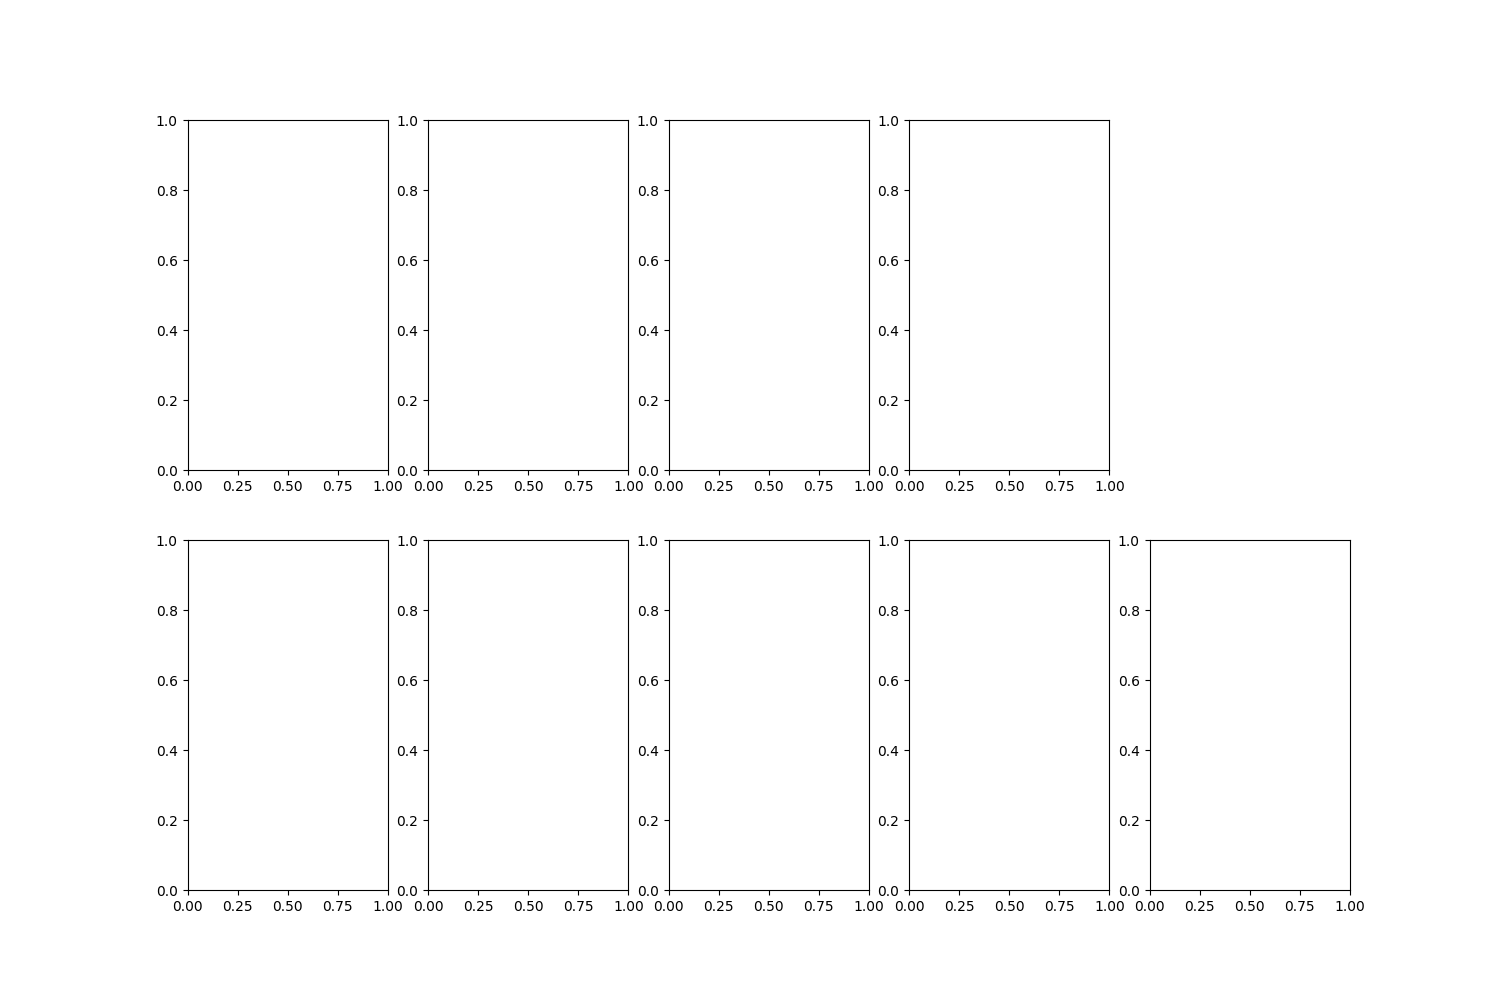

In [24]:
fig,axes = plt.subplots(2, int(((len(temp_dict_climate)+1) /2)+.5), figsize=[15,10])
fig.delaxes(axes[0,-1])

temperature_residuals_with_offset = []

for name, ax in zip(temp_dict_climate, fig.axes[:-1]):




    ### Calculate the offset between the model and the observations ###
    N = 0
    for i in avg_temps:
        if i.startswith(name):
            try:
                if N == 0 :
                    z_offset = temp_dict_climate[name][1][:,2][-1] - core_surface_z[name]
                    f = scipy.interpolate.interp1d(temp_dict_climate[name][1][:,2] - z_offset, temp_dict_climate[name][0])

                    model_temps_at_obs = f(avg_temps[i][0])

                    model_temp_offsets =  avg_temps[i][2] - model_temps_at_obs
                    model_temp_offset_mean = np.mean(model_temp_offsets.values[40:])
                    


                    residuals_with_offset = (model_temps_at_obs + model_temp_offset_mean) - avg_temps[i][2].values
                    print(name)
                    temperature_residuals_with_offset.append(np.mean(np.abs(residuals_with_offset[40:])))
                    print(np.mean(np.abs(residuals_with_offset[40:])))
                    N += 1



            except:
                if N == 0 :
                    f = scipy.interpolate.interp1d(avg_temps[i][0], avg_temps[i][2])

                    real_temps_at_model = f(temp_dict_climate[name][1][:,2] - z_offset)

                    real_temp_offsets = temp_dict_climate[name][0] - real_temps_at_model
                    real_temp_offsets_mean = np.mean(real_temp_offsets[:-2])

                    model_temp_offset_mean = real_temp_offsets_mean *-1

                    residuals_with_offset = (temp_dict_climate[name][0] + model_temp_offset_mean) - real_temps_at_model
                    print(name)
                    temperature_residuals_with_offset.append(np.mean(np.abs(residuals_with_offset)))
                    print(np.mean(np.abs(residuals_with_offset)))

                    N += 1





    try:

        z_offset = temp_dict_climate[name][1][:,2][-1] - core_surface_z[name]
        ax.plot(temp_dict_climate[name][0]+ model_temp_offset_mean, temp_dict_climate[name][1][:,2] - z_offset, c='black',label='Model (with climate)')
        ax.plot(temp_dict_no_climate[name][0]+ model_temp_offset_mean, temp_dict_no_climate[name][1][:,2] - z_offset, c='black', label='Model (steady state)', ls = '--')

        axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
        axinses.plot(scipy.signal.detrend(temp_dict_climate[name][0][:-1]), temp_dict_climate[name][1][:,2][:-1]-z_offset, c='black')
        axinses.plot(scipy.signal.detrend(temp_dict_no_climate[name][0][:-1]), temp_dict_no_climate[name][1][:,2][:-1]-z_offset, ls = '--',c='black')


        ax.annotate('model temperature offset: {:.2f}$^\circ$C'.format(model_temp_offset_mean), xy=(0.01, 0.01), xycoords='axes fraction')
        
    except:
        
        ax.plot(temp_dict_climate[name][0], temp_dict_climate[name][1][:,2], c='black', label='Model')
        ax.plot(temp_dict_no_climate[name][0], temp_dict_no_climate[name][1][:,2], c='black', label='Model (steady state)', ls = '--')

        axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
        axinses.plot(scipy.signal.detrend(temp_dict_climate[name][0][:-1]), temp_dict_climate[name][1][:,2][:-1], c='black')
        axinses.plot(scipy.signal.detrend(temp_dict_no_climate[name][0][:-1]), temp_dict_no_climate[name][1][:,2][:-1], ls = '--',c='black')


        min_temp = temp_dict_no_climate[name][0].min()
        ax.set_xlim([min_temp - 2, -10])

    ax.set_title(name)


    for i in avg_temps:
        if i.startswith(name):
            if i[-2:] == '22':
                color = 'steelblue'
            elif i[-2:] == '23':
                color = 'indianred'
            elif i[-2:] == '24':
                color = 'forestgreen'
            ax.plot(avg_temps[i][2], avg_temps[i][0], label=i[-2:]+' Season',c=color)
            axinses.plot(residual_temps[i][2], residual_temps[i][0], label=i[-2:]+' Season',c=color)

            min_temp = avg_temps[i][2].min()
            ax.set_xlim([min_temp - 2, -10])
    if name == 'ALHIC1901':
        leg = ax.legend( loc = 'upper right')

fig.axes[0].set_ylabel('Elevation (m)')
fig.axes[0].set_xlabel('Temperature (C)')



### Plot the synthetic borehole temperature profile ###

temp_fast_temps = []
temp_fast_temps_clim = []
temp_fast_depths = []
for z_bore in np.linspace(1300,2000,50):
    try:
        temp_fast = T_init.at(510000, -1.3559e6, z_bore)
        temp_fast_clim = Ts[-1].at(510000, -1.3559e6, z_bore)
        temp_fast_temps.append(temp_fast)
        temp_fast_temps_clim.append(temp_fast_clim)
        temp_fast_depths.append(z_bore)
    except:
        continue

axes[1,-1].plot(temp_fast_temps, temp_fast_depths, c='black', ls='--')
axes[1,-1].plot(temp_fast_temps_clim, temp_fast_depths, c='black')

min_temp = np.array(temp_fast_temps).min()
axes[1,-1].set_xlim([min_temp - 2, -10])
axinses = inset_axes(axes[1,-1], width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=axes[1,-1].transAxes, borderpad=1)

axinses.plot(scipy.signal.detrend(temp_fast_temps), temp_fast_depths, c='black', ls='--')
axinses.plot(scipy.signal.detrend(temp_fast_temps_clim), temp_fast_depths, c='black')
axes[1,-1].set_title('Synthetic Borehole in Fast Flow')

# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(axes[1,-1].transAxes.inverted()) 

# Change to location of the legend. 
xOffset = 4.5
bb.x0 += xOffset
bb.x1 += xOffset
leg.set_bbox_to_anchor(bb, transform = axes[1,-1].transAxes)

plt.tight_layout()

plt.subplots_adjust(right=1.1)

plt.show()



# plt.savefig('Figures/fig2_updated_80m.eps', dpi=300, bbox_inches='tight', format='eps', transparent=True)
# plt.savefig('Figures/fig2_updated_80m.png', dpi=300, bbox_inches='tight', format='png', transparent=False)

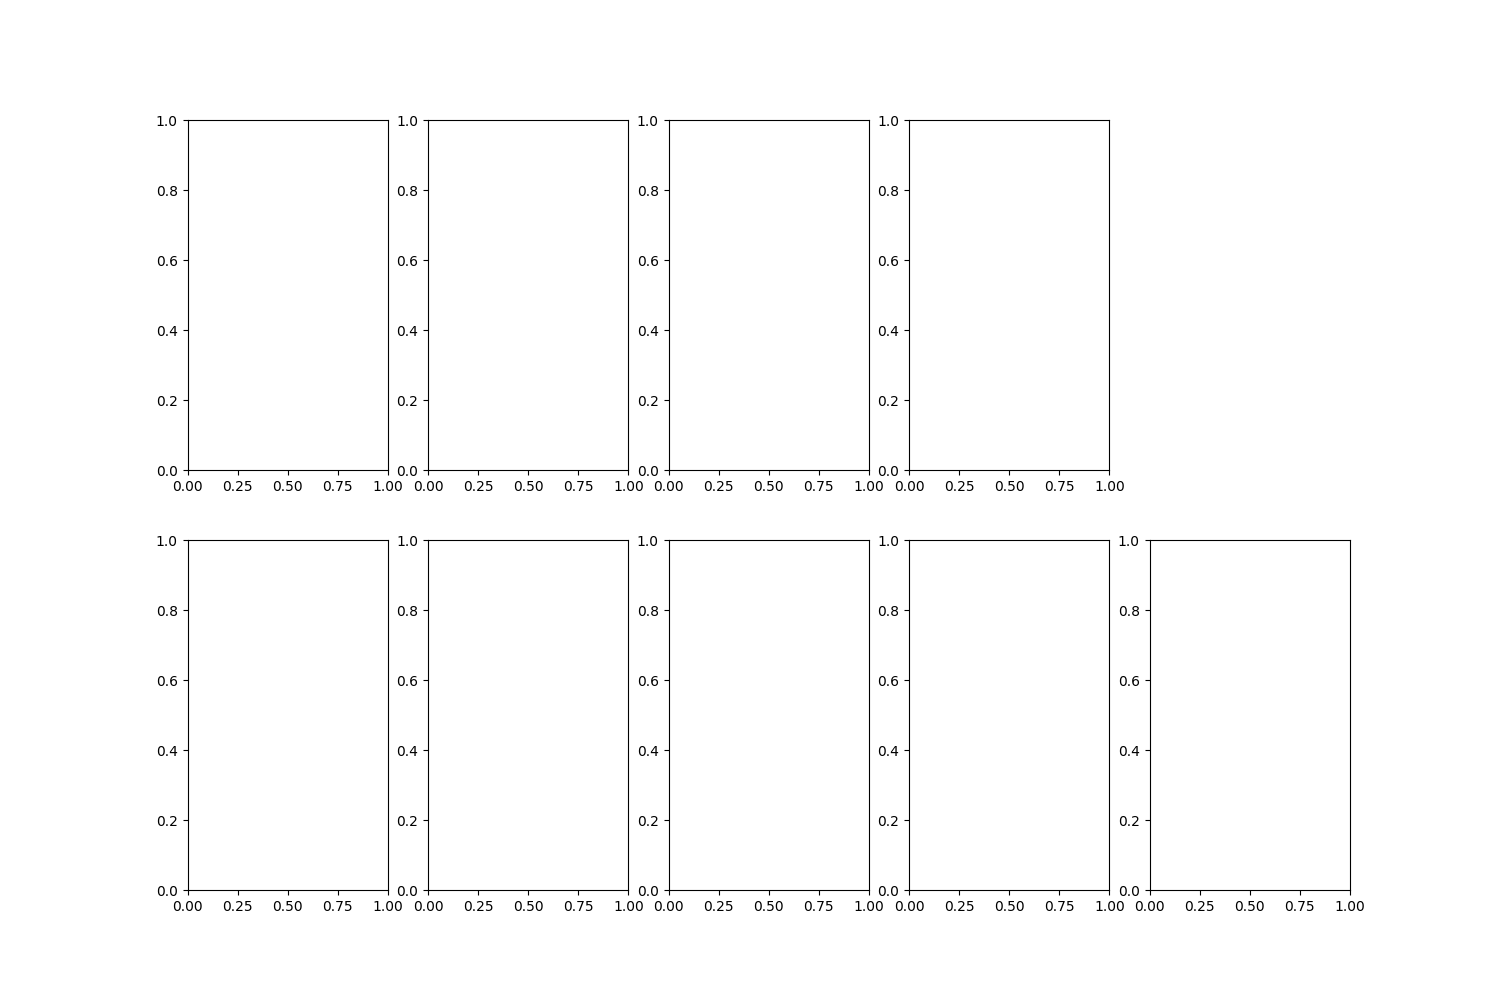

In [38]:
fig,axes = plt.subplots(2, int(((len(temp_dict_climate)+1) /2)+.5), figsize=[15,10])
fig.delaxes(axes[0,-1])